[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SebastianSamanieg/data_analytics_study/blob/trunk/case_analysis/eda/explore_data.ipynb)

# 📊 Exploratory Data Analysis (EDA)

El **Análisis Exploratorio de Datos (EDA, por sus siglas en inglés)** es el proceso inicial en un proyecto de análisis o ciencia de datos.
Su objetivo es **explorar, comprender y resumir** las principales características del dataset antes de aplicar modelos o sacar conclusiones.

A través del EDA podemos:
- Identificar valores faltantes, atípicos o inconsistentes.
- Revisar la distribución de las variables (numéricas y categóricas).
- Detectar correlaciones y relaciones entre columnas.
- Generar resúmenes estadísticos y visualizaciones que faciliten la interpretación de los datos.

---

## 🚀 EDA con Sweetviz

En este proyecto utilizamos la librería **Sweetviz**, que permite automatizar gran parte del EDA y generar un **informe interactivo**.
Sweetviz analiza el dataset y crea gráficos y métricas que nos ayudan a:

- Describir la distribución de cada variable.
- Comparar subconjuntos de datos (por ejemplo, `train` vs `test`).
- Visualizar valores faltantes y outliers.
- Explorar la relación de cada variable con la variable objetivo (si existe).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 📥 INSTALACIÓN DE LIBRERÍAS COLAB
# ═══════════════════════════════════════════════════════════════════════════════

!pip install -q -r https://raw.githubusercontent.com/SebastianSamanieg/data_analytics_study/trunk/requirements-colab.txt

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 📥 INSTALACIÓN DE LIBRERÍAS LOCAL WINDOWS
# ═══════════════════════════════════════════════════════════════════════════════

!pip install -q -r https://raw.githubusercontent.com/SebastianSamanieg/data_analytics_study/trunk/requirements.txt

^C


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# 🔄 LIBRARY IMPORT
# ═══════════════════════════════════════════════════════════════════════════════

# ───────────────────────────────────────────────────────────────────────────────
# 📚 Standard libraries
# ───────────────────────────────────────────────────────────────────────────────
import warnings

# ───────────────────────────────────────────────────────────────────────────────
# ✏️ Data manipulation
# ───────────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

# ───────────────────────────────────────────────────────────────────────────────
# 📊 Visualization
# ───────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import ipywidgets

# ───────────────────────────────────────────────────────────────────────────────
# 🤖 Machine Learning
# ───────────────────────────────────────────────────────────────────────────────
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# ───────────────────────────────────────────────────────────────────────────────
# ⛔ Ignore warnings for cleaner output
# ───────────────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore", category=UserWarning, module="sweetviz")


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1. CARGA Y EXPLORACIÓN INICIAL DEL DATASET
# ═══════════════════════════════════════════════════════════════════════════════

ruta = os.path.join("../datasets", "raw_data", "BASETICMUJER.xlsx")

print("Ruta final:", ruta)
print("Split:", os.path.splitext(ruta))

df = pd.read_excel(ruta)
print("✅ Base cargada, filas:", len(df))


Ruta final: ../datasets\raw_data\BASETICMUJER.xlsx
Split: ('../datasets\\raw_data\\BASETICMUJER', '.xlsx')
✅ Base cargada, filas: 65879


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65879 entries, 0 to 65878
Data columns (total 35 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Tipo Servicio                                    65879 non-null  object
 1   Fecha de Nacimiento                              65879 non-null  int64 
 2   Edad                                             65879 non-null  int64 
 3   Zona                                             65879 non-null  object
 4   Ocupacion                                        65879 non-null  object
 5   Conflicto                                        65879 non-null  object
 6   Comunidad lgbtiq                                 65879 non-null  object
 7   Ciclo                                            65879 non-null  object
 8   Tipo emprendimiento                              65879 non-null  object
 9   Cursos                                 

                                             |          | [  0%]   00:00 -> (? left)

AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'

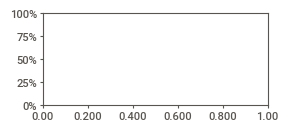

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2. ANÁLISIS EXPLORATORIO AUTOMÁTICO CON SWEETVIZ
# ═══════════════════════════════════════════════════════════════════════════════

# ───────────────────────────────────────────────────────────────────────────────
# Analizar el DataFrame completo
# ───────────────────────────────────────────────────────────────────────────────
report = sv.analyze(df)

# ───────────────────────────────────────────────────────────────────────────────
# Guardar el reporte como HTML
# ───────────────────────────────────────────────────────────────────────────────
report.show_html("Report.html")

print("✅ Reporte generado: Report.html")

# ───────────────────────────────────────────────────────────────────────────────
# Detectar columnas con tipos mixtos y convertirlas a str
# ───────────────────────────────────────────────────────────────────────────────
for col in df.columns:
    if df[col].infer_objects().dtype == "object" and df[col].map(type).nunique() > 1:
        df[col] = df[col].astype(str)

# ───────────────────────────────────────────────────────────────────────────────
# Ahora correr Sweetviz
# ───────────────────────────────────────────────────────────────────────────────
report = sv.analyze(df)
report.show_html("Report.html")

# ───────────────────────────────────────────────────────────────────────────────
# 🔧 Parche temporal para compatibilidad con Sweetviz y NumPy 2.x
# ───────────────────────────────────────────────────────────────────────────────
if not hasattr(np, "VisibleDeprecationWarning"):
    class VisibleDeprecationWarning(UserWarning):
        pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

# ───────────────────────────────────────────────────────────────────────────────
# Análisis sv
# ───────────────────────────────────────────────────────────────────────────────
report = sv.analyze(df)
report.show_html("Report.html")


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. COMPARACIÓN TRAIN-TEST CON SWEETVIZ
# ═══════════════════════════════════════════════════════════════════════════════

# ───────────────────────────────────────────────────────────────────────────────
# Split the dataset
# ───────────────────────────────────────────────────────────────────────────────
train_df, test_df = train_test_split(df, train_size=0.75)

# ───────────────────────────────────────────────────────────────────────────────
# Compare the dataset
# ───────────────────────────────────────────────────────────────────────────────
compare = sv.compare(source=train_df, compare=test_df, target_feat="Edad")

# ───────────────────────────────────────────────────────────────────────────────
# Show the result
# ───────────────────────────────────────────────────────────────────────────────
compare.show_html('Compare.html')

                                             |          | [  0%]   00:00 -> (? left)

Report Compare.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. REPORTE EDA AUTOMÁTICO CON YDATA-PROFILING (EDA)
# ═══════════════════════════════════════════════════════════════════════════════

profile = ProfileReport(df, title="EDA Report", explorative=True)
profile.to_file("EDA_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 35/35 [00:05<00:00,  6.93it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]